<a href="https://colab.research.google.com/github/24csa3bc088/Codec_Task_2/blob/T2/CodecTask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


file_path = "/content/drive/MyDrive/test(grayscale).csv"
data = pd.read_csv(file_path)


X = data.drop(['label', 'Index'], axis=1).values
y = data['label'].values


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y).astype(np.int64)

In [3]:
X = X / 255.0


X = X.reshape(-1, 32, 32, 1)

In [4]:
import numpy as np

print(np.unique(y))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.2821 - loss: 3.6491 - val_accuracy: 0.0075 - val_loss: 39.9185
Epoch 2/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.8864 - loss: 0.3695 - val_accuracy: 0.0083 - val_loss: 45.6553
Epoch 3/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 78s 40ms/step - accuracy: 0.9486 - loss: 0.1633 - val_accuracy: 0.0096 - val_loss: 48.9550
Epoch 4/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9667 - loss: 0.1054 - val_accuracy: 0.0091 - val_loss: 50.5238
Epoch 5/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9745 - loss: 0.0808 - val_accuracy: 0.0070 - val_loss: 47.0575
Epoch 6/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.9809 - loss: 0.0614 - val_accuracy: 0.0101 - val_loss: 48.7917
Epoch 7/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.9840 - loss: 0.0536 - val_accuracy: 0.0087 - val_loss: 47.1393
Epoch 8/10
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0

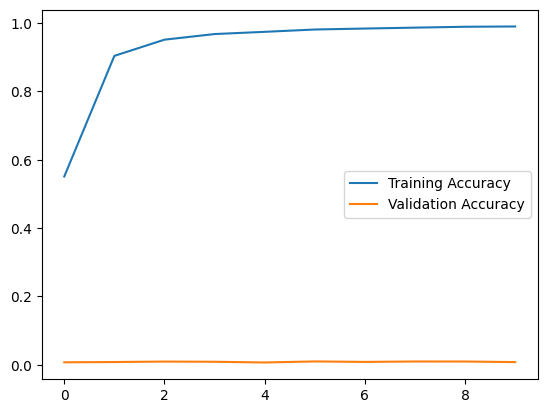

In [5]:
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Model definition (input shape corrected in a previous step)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(np.unique(y)), activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X, y, epochs=10, validation_split=0.2)


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X)
y_pred_classes = np.argmax(y_pred, axis=1)
print(confusion_matrix(y, y_pred_classes))
print(classification_report(y, y_pred_classes))

1896/1896 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step
[[158   0   0 ...   0   0   0]
 [  0 158   0 ...   0   0   0]
 [  0   0 158 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       158
           1       1.00      1.00      1.00       158
           2       0.93      1.00      0.96       158
           3       0.98      0.97      0.97       158
           4       0.66      1.00      0.79       158
           5       0.46      1.00      0.63       158
           6       0.99      1.00      0.99       158
           7       0.98      1.00      0.99       158
           8       0.96      0.99      0.98       158
           9       1.00      1.00      1.00       158
          10       0.90      1.00      0.95       158
          11       0.99      0.97      0.98       158
          12       1.00      0.99      1.00       158
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


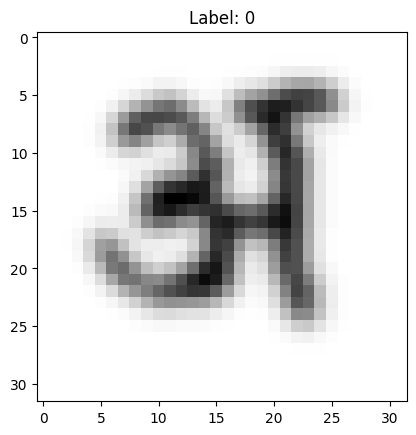

In [7]:
import matplotlib.pyplot as plt
plt.imshow(X[0].reshape(32, 32), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

In [8]:
layers.Dropout(0.2)

<Dropout name=dropout, built=True>

In [9]:
layers.BatchNormalization()

<BatchNormalization name=batch_normalization, built=False>

In [10]:
predictions = model.predict(X[:5])
print(np.argmax(predictions, axis=1))
print(y[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[0 0 0 0 0]
[0 0 0 0 0]


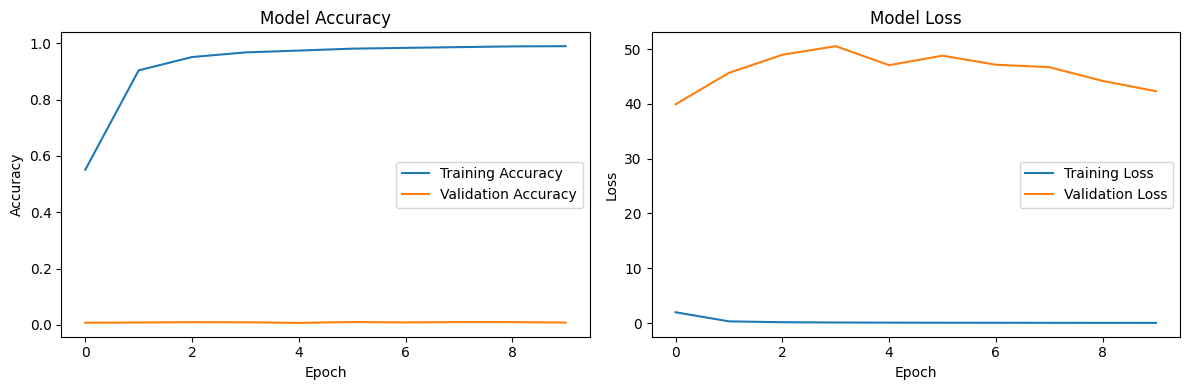

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()